In [5]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.subplots as sp

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    MaxAbsScaler,
    RobustScaler,
    PowerTransformer,
    QuantileTransformer,
    Normalizer
)
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from scipy.interpolate import interp1d
from scipy.fft import fft, ifft
from scipy.signal import savgol_filter
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder

#Statistical Method
from sklearn.linear_model import LinearRegression

#Imputation Methods
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, HTML

# Hide output scroll bars
display(HTML("<style>.output_area {max-height: none;}</style>"))

In [6]:
# Load sample financial data
df = pd.read_csv('MSTR_2024.csv')  # Replace with actual dataset

In [7]:
#Keep Date separate
dfDate = df['Date']

# Select features and target variable
features = ['Open', 'High', 'Low', 'Adj Close', 'Volume', 'SMA_20', 'SMA_50', 'Upper_BB', 'Middle_BB', 'Lower_BB',
            'RSI_14', 'MACD', 'Signal', 'Stochastic', 'ROC', 'CCI', 'OBV', 'ATR', 'STD_20', 'VAR_20']
target = 'Close'

#Strip Column spaces, modify date string etc.
df.columns = df.columns.str.strip()

#Eliminate Stock Split rows and any other NANs.
rowIndexToDrop = df[df.isnull().any(axis=1)]
df.iloc[rowIndexToDrop.index]
df = df.drop(rowIndexToDrop.index)
df = df.reset_index(drop=True)
# Make sure they're gone.
df[df.isnull().any(axis=1)]

#Convert text $ values to numeric for calculations. The r before the \$ indicates it's a raw string to avoid the escape \ character.
df['Open'] = df['Open'].replace({r'\$': '', ',': ''}, regex=True)
df['High'] = df['High'].replace({r'\$': '', ',': ''}, regex=True)
df['Low'] = df['Low'].replace({r'\$': '', ',': ''}, regex=True)
df['Close'] = df['Close'].replace({r'\$': '', ',': ''}, regex=True)
df['Adj Close'] = df['Adj Close'].replace({r'\$': '', ',': ''}, regex=True)
df['Volume'] = df['Volume'].replace({r'\$': '', ',': ''}, regex=True)
df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']] = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].apply(pd.to_numeric)
df = df[['Close','Open','High','Low','Adj Close','Volume']]

# Forward-fill missing values
df.fillna(method='ffill', inplace=True)

# Convert non-numeric data fields.
df = df.apply(pd.to_numeric, errors='coerce')

In [8]:
def simple_moving_average(series, window):
    return series.rolling(window=window).mean()

def bollinger_bands(series, window=20, num_std_dev=2):
    sma = simple_moving_average(series, window)
    rolling_std = series.rolling(window=window).std()
    upper_band = sma + (rolling_std * num_std_dev)
    lower_band = sma - (rolling_std * num_std_dev)
    return upper_band, sma, lower_band

def rsi(series, window=14):
    delta = series.diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def macd(series, short_window=12, long_window=26, signal_window=9):
    short_ema = series.ewm(span=short_window, adjust=False).mean()
    long_ema = series.ewm(span=long_window, adjust=False).mean()
    macd_line = short_ema - long_ema
    signal_line = macd_line.ewm(span=signal_window, adjust=False).mean()
    return macd_line, signal_line

def stochastic_oscillator(highs, lows, closes, window=14):
    lowest_low = lows.rolling(window=window).min()
    highest_high = highs.rolling(window=window).max()
    return 100 * (closes - lowest_low) / (highest_high - lowest_low)

def rate_of_change(series, window=12):
    return series.pct_change(periods=window) * 100

def commodity_channel_index(highs, lows, closes, window=20):
    typical_price = (highs + lows + closes) / 3
    sma = simple_moving_average(typical_price, window)
    mean_deviation = typical_price.rolling(window=window).apply(lambda x: np.mean(np.abs(x - np.mean(x))))
    return (typical_price - sma) / (0.015 * mean_deviation)

def on_balance_volume(closes, volumes):
    obv = (np.sign(closes.diff()) * volumes).fillna(0).cumsum()
    return obv

def average_true_range(highs, lows, closes, window=14):
    tr1 = highs - lows
    tr2 = np.abs(highs - closes.shift(1))
    tr3 = np.abs(lows - closes.shift(1))
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    return tr.rolling(window=window).mean()

def linear_regression_trend(series):
    x = np.arange(len(series)).reshape(-1, 1)
    y = series.values.reshape(-1, 1)
    model = LinearRegression().fit(x, y)
    return model.predict(x).flatten()

def standard_deviation(series, window=20):
    return series.rolling(window=window).std()

def variance(series, window=20):
    return series.rolling(window=window).var()

In [9]:
#Technical Indicator Calculations
df['SMA_20'] = simple_moving_average(df['Close'], 20)
df['SMA_50'] = simple_moving_average(df['Close'], 50)
df['Upper_BB'], df['Middle_BB'], df['Lower_BB'] = bollinger_bands(df['Close'], 20)
df['RSI_14'] = rsi(df['Close'], 14)
df['MACD'], df['Signal'] = macd(df['Close'])
df['Stochastic'] = stochastic_oscillator(df['High'], df['Low'], df['Close'])
df['ROC'] = rate_of_change(df['Close'])
df['CCI'] = commodity_channel_index(df['High'], df['Low'], df['Close'])
df['OBV'] = on_balance_volume(df['Close'], df['Volume'])
df['ATR'] = average_true_range(df['High'], df['Low'], df['Close'])
df['STD_20'] = standard_deviation(df['Close'])
df['VAR_20'] = variance(df['Close'])

In [10]:
#Imputation
df_features = df[features] #Select only columns to impute and keep target separate.

# Mean Imputation
imputer = SimpleImputer(strategy='mean')  # or use 'median', 'most_frequent', etc.
df_imputed_Simple = pd.DataFrame(imputer.fit_transform(df_features), columns=df_features.columns)

# KNN Imputation
knn_imputer = KNNImputer(n_neighbors=5)
df_imputed_knn = pd.DataFrame(knn_imputer.fit_transform(df_features), columns=df_features.columns)

#Iterative Imputation
imputer = IterativeImputer()
df_imputed_iterative = pd.DataFrame(imputer.fit_transform(df_features), columns=df_features.columns)

In [11]:
# List of imputed dataframes
imputed_dfs = [df_imputed_Simple, df_imputed_knn, df_imputed_iterative]
imputed_df_names = ['Simple', 'KNN', 'Iterative']

# Loop through each imputed dataframe
for df_imputed, name in zip(imputed_dfs, imputed_df_names):
    # Combine the imputed features with the target and date
    df_combined = pd.concat([df_imputed, df['Close'], dfDate], axis=1)

    # Drop any remaining rows with NaN values
    df_combined = df_combined.dropna()

    # Reset index after dropping rows
    df_combined = df_combined.reset_index(drop=True)

    # Print out the shape of the cleaned dataframe
    print(f"{name} Imputed DataFrame after removing NaNs: {df_combined.shape}")

    # If you want to store the cleaned dataframes for later use:
    globals()[f"df_imputed_cleaned_{name}"] = df_combined

# New dataframes are df_imputed_cleaned_Iterative, df_imputed_cleaned_KNN, df_imputed_cleaned_Simple

Simple Imputed DataFrame after removing NaNs: (251, 22)
KNN Imputed DataFrame after removing NaNs: (251, 22)
Iterative Imputed DataFrame after removing NaNs: (251, 22)


In [17]:
# Define the scalers you want to apply
scalers = {
    "Unscaled data": None,
    "Standard Scaler": StandardScaler(),
    "MinMax Scaler": MinMaxScaler(),
    "MaxAbs Scaler": MaxAbsScaler(),
    "Robust Scaler": RobustScaler(),
    "Power Transformer (Yeo-Johnson)": PowerTransformer(method="yeo-johnson"),
    "Quantile Transformer (Uniform)": QuantileTransformer(output_distribution="uniform"),
    "Quantile Transformer (Gaussian)": QuantileTransformer(output_distribution="normal"),
    "Normalizer": Normalizer()
}

# List of imputed dataframes
imputed_dfs = [df_imputed_cleaned_Iterative, df_imputed_cleaned_KNN, df_imputed_cleaned_Simple]
df_names = ['df_imputed_cleaned_Iterative', 'df_imputed_cleaned_KNN', 'df_imputed_cleaned_Simple']

# List to store scaled data
scaled_dfs = {}

# Train models with different scalers and evaluate performance
results = {}

# For each scaler, apply cross-validation
cv_results = {}

# Scale the data using each scaler
for df, df_name in zip(imputed_dfs, df_names):
    for scaler_name, scaler in scalers.items():
        # Create the datasets for statistical analysis
        X = df.drop(columns=['Close', 'Date'])
        y = df['Close']
        # Train-Test Split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        if scaler is None:  # If no scaling, just keep the unscaled data
            scaled_data = X_train
        else:
            # Scale the data
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
    
            # Train a model
            model = LinearRegression()
            model.fit(X_train_scaled, y_train)

            #Cross Validation
            X_scaled = scaler.fit_transform(X)
            cv_score = cross_val_score(model, X_scaled, y, cv=5, scoring='neg_mean_squared_error')  # Negative MSE for minimization
            cv_results[scaler_name] = cv_score.mean()
            
            # Predict and evaluate
            y_pred = model.predict(X_test_scaled)
            mse = mean_squared_error(y_test, y_pred)
    
            # Store the results
            results[scaler_name] = mse
        
        # Store the scaled data in the dictionary with a key indicating both the dataframe and the scaler
        scaled_dfs[f"{df_name}_{scaler_name}"] = pd.DataFrame(scaled_data, columns=features)

# Now `scaled_dfs` contains the scaled dataframes, you can process or visualize them further as needed

In [32]:
# Print the results for comparison
print("MSE for different scalers:", results)

MSE for different scalers:                             Scaler           MSE
2                    MaxAbs Scaler  1.087255e-26
0                  Standard Scaler  1.531442e-26
1                    MinMax Scaler  1.798331e-26
3                    Robust Scaler  7.163684e-25
4  Power Transformer (Yeo-Johnson)  3.118114e+02
6  Quantile Transformer (Gaussian)  6.044593e+02
5   Quantile Transformer (Uniform)  8.541617e+02
7                       Normalizer  2.468066e+03


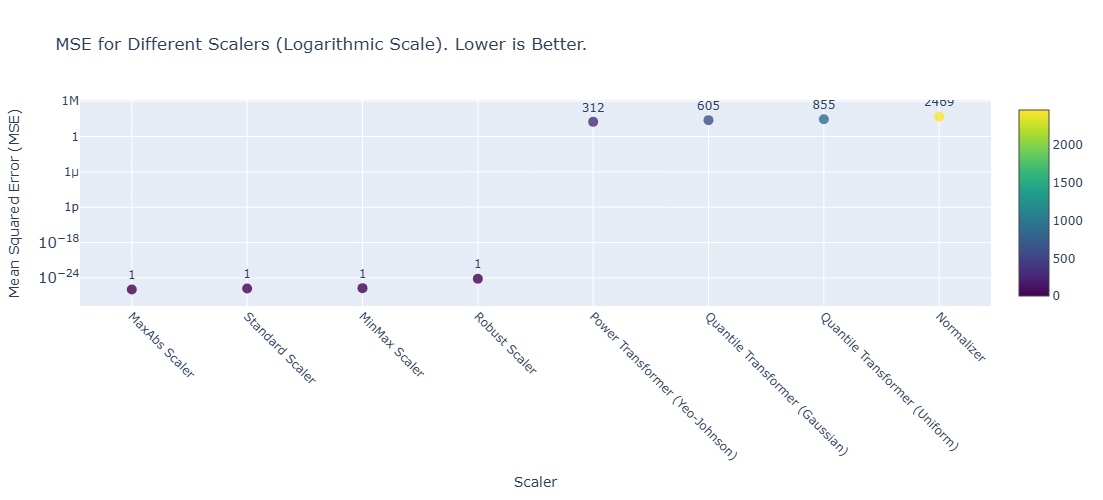

In [42]:
# Sort the results by MSE (ascending) so that the best scalers (lowest MSE) are at the top
results = results.sort_values(by='MSE', ascending=True)

# Round up the MSE values
results['Rounded_MSE'] = np.ceil(results['MSE'])

# Create the dot chart
fig = go.Figure()

# Add scatter plot (dot chart) for MSE values across different scalers
fig.add_trace(go.Scatter(
    x=results['Scaler'],  # X-axis: Scaler names from 'results'
    y=results['MSE'],  # Y-axis: MSE values from 'results'
    mode='markers+text',  # Use markers (dots) and also display text labels
    marker=dict(
        size=10,  # Set a fixed small size for the dots
        color=results['MSE'],  # Color the dots based on MSE
        colorscale='Viridis',  # Choose a color scale
        showscale=True,  # Show the color scale
        opacity=0.8  # Make the dots slightly transparent
    ),
    text=results['Rounded_MSE'],  # Display the rounded-up MSE value as text
    textposition='top center',  # Position text above the dots
    name="Scaler MSE"
))

# Update layout for better presentation
fig.update_layout(
    title="MSE for Different Scalers (Logarithmic Scale). Lower is Better.",
    xaxis_title="Scaler",
    yaxis_title="Mean Squared Error (MSE)",
    template="plotly",
    showlegend=False,
    height=500,
    xaxis=dict(tickangle=45),  # Rotate scaler names for better readability
    yaxis=dict(
        type="log",  # Apply a logarithmic scale to the y-axis
        autorange=True,  # Automatically adjust the y-axis range
        showgrid=True  # Show gridlines for better readability
    )
)

# Show the plot
fig.show()

In [46]:
# Print the results for cross-validation
print("Cross-validation MSE for different scalers:", cv_results)

Cross-validation MSE for different scalers: {'MinMaxScaler': -0.035, 'StandardScaler': -0.03, 'RobustScaler': -0.032}


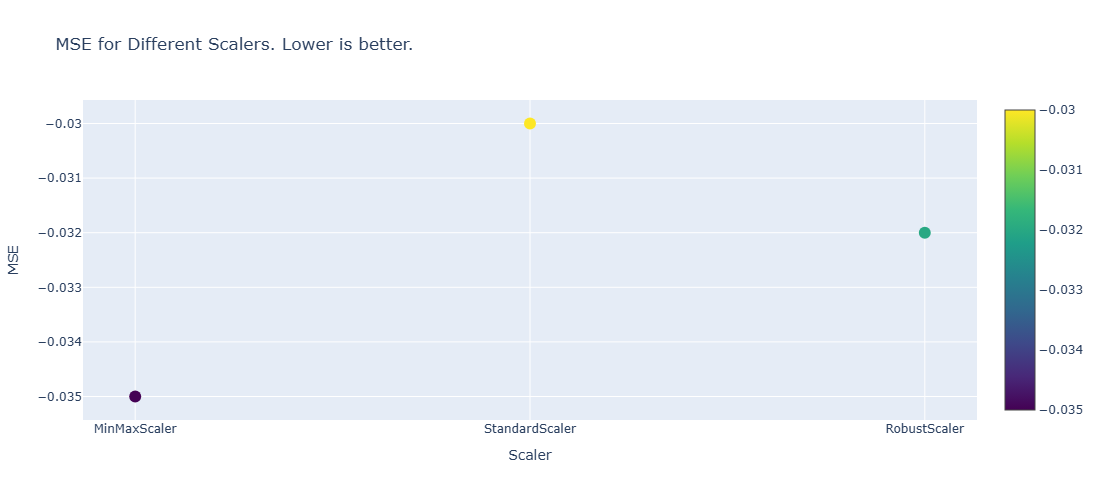

In [50]:
# Convert the dictionary to a DataFrame
scalers_mse = cv_results

# Convert dictionary into lists for plotting
scalers = list(scalers_mse.keys())
mse_values = list(scalers_mse.values())

# Create the scatter plot
fig = go.Figure()

# Add scatter plot trace
fig.add_trace(go.Scatter(
    x=scalers,  # X-axis: Scaler names
    y=mse_values,  # Y-axis: MSE values
    mode='markers',  # Use markers (dots)
    marker=dict(
        size=12,  # Set size of the dots
        color=mse_values,  # Color the dots based on MSE values
        colorscale='Viridis',  # Color scale
        showscale=True  # Show color scale
    ),
    text=mse_values,  # Show MSE value on hover
    name="Scaler MSE"
))

# Update layout
fig.update_layout(
    title="MSE for Different Scalers. Lower is better.",
    xaxis_title="Scaler",
    yaxis_title="MSE",
    template="plotly",
    showlegend=False,
    height=500,
)

# Show the plot
fig.show()